# Neutral Mutation Rates for Sites of Interest

## Introduction

In our V family DASM analysis, we discovered an intriguing pattern at specific sites located at the edges of CDRs (main sites: 38, 55, 40, 57, 66). These sites exhibit a paradoxical combination of properties:

1. **Wide germline heterogeneity** - Multiple different amino acids are present across V gene families at these positions
2. **Entrenchment** - Despite this heterogeneity, there is a strong preference not to mutate between the different germline amino acids


We load entrenchment results from DASM analysis from _output/entrenchment_analysis (see vj_families_dasm for creation).

We separate sites into two types of evolutionarily constrained sites:
- **Within v family entrenched sites**
- **Between v-family entrenched sites**

Sites can get an entrenchment signal in both, and then it is unclear if the sites became entrenched at the evolutionary level while separating into v families or v genes.
For simplicity, we create a simple separation into sites that are entrenched within v families, and sites that are entrenched between v families and not within v families.
The "within v family" tend to cluster in and close to the CDRs, and the "between v families" can be seen in other places as well (cell 5). We can hypothesize that between v family sites are likely very constrained in the antibody, with other structural features in the antibody preventing a mutation to the previous state, and that the within v family sites are more related to binding and the antigen, as they are close/in CDR areas and also at sites that have high germline diversity.

## Get neutral mutation rates from thrifty
We examine the **neutral mutation rates** at these sites using the Thrifty model. Our hypothesis is that entrenchment might correlate with intrinsic mutational properties of these positions.

We calculate neutral mutation probabilities (cell 2) using:
- The Thrifty neutral mutation model to predict position-specific rates
- A standardized branch length of 0.1 to ensure comparable rates across sites and amino acids
- Calculate specific substitution probabilities: substitution_probability = probability * csp
- We calculate neutral probabilties per nucleotide>nucleotide, translate that to amino acid changes, and then aggregate to create two dataframes:
   - aa_neutral_df - neutral probabilitiy of specific amino acid to specific amino acid
   - aa_to_any_neutral_df - neutral probability of specific amino acid to any

## We find high neutral mutation rate for these sites

**Surprising Result**: Thrifty reveals that these entrenchment sites actually have **high neutral mutation rates** (cell 8). This is more true for the "within v family entrenched sites" and not so much for the "bewteen v family entrenched sites". For all of these analyses we focus on mutations away from the germline only. 

## Neutral rate and germline diversity
Hypothesis: looking at the v genes, some sites are more heterogenous then others. Perhaps site-level heterogeneity in V genes might be driven by underlying neutral mutation rates rather than selection, because the gene duplication events that create the germline diversity happen at the DNA level before any functional protein exists (can AID occur at the gamete level?). We can test this by comparing neutral mutation patterns (thrifty) to germline diversity (both the level of diversity per site and also specific mutations that occur).

We find that there is a correlation between shannon diversity at a site and neutral mutation rate (cell 16):
- There is a correlation of r^2=0.136 for mean median substitution probability per site vs shannon diversity per site on all data for V1, V3, V4. When we remove sites with diversity < 0.2, we get a higher correlation of r^2=0.195, unlike the correlation with selection factors which disappears after this filtration.
- Follow up - is the mutation pattern also correlated? We can check if the tree of the germline v genes is better explained by a model of the trhufty neutral rates site, compared to a uniform model.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import glob
from scipy.stats import pearsonr, spearmanr


from netam.models import DEFAULT_NEUTRAL_MODEL
from dnsmex.local import localify
from dnsmex.neutral_mutability import CachedNeutralMutabilityDataset
from dnsmex.dasm_oe import write_sites_oe
from utils import add_germline_information, sort_antibody_sites, load_and_process_dnsm_data, load_and_process_dasm_data, is_in_cdr, GERMLINE_PATH_DICTIONARY, load_entrenched_sites, add_cdr_shading


figures_dir = localify("FIGURES_DIR")

In [2]:
numbering_scheme = 'chothia'

MutabilityContainer = CachedNeutralMutabilityDataset(
    dataset_nickname="v1rodriguez",
    branch_length_mode='constant',
    branch_length=0.1,
    numbering_scheme=numbering_scheme
)

# add germline information to all dataframes
MutabilityContainer.aa_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.aa_neutral_df, numbering_scheme=numbering_scheme)
MutabilityContainer.aa_to_any_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.aa_to_any_neutral_df, numbering_scheme=numbering_scheme)
MutabilityContainer.codon_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.codon_neutral_df, numbering_scheme=numbering_scheme)
MutabilityContainer.codon_to_any_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.codon_to_any_neutral_df, numbering_scheme=numbering_scheme)

Loading NeutralMutabilityDataset data from gzip cache...


✓ Loaded from gzip cache:
  - Nucleotide DataFrame: 31,773,960 rows
  - Amino Acid DataFrame: 18,598,930 rows
  - Amino Acid to Any DataFrame: 2,647,830 rows
  - Codon DataFrame: 23,830,470 rows
  - Codon to Any DataFrame: 2,647,830 rows
  - PCP DataFrame: 21,752 rows


In [3]:
# Sort sites properly
sorted_sites = sort_antibody_sites(MutabilityContainer.aa_to_any_neutral_df['site'].unique())

# Convert to categorical with proper ordering
MutabilityContainer.aa_to_any_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.aa_to_any_neutral_df['site'], 
    categories=sorted_sites, 
    ordered=True
)

MutabilityContainer.aa_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.aa_neutral_df['site'], 
    categories=sorted_sites, 
    ordered=True
)

MutabilityContainer.codon_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.codon_neutral_df['site'], 
    categories=sorted_sites, 
    ordered=True
)

MutabilityContainer.codon_to_any_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.codon_to_any_neutral_df['site'], 
    categories=sorted_sites, 
    ordered=True
)

MutabilityContainer.nuc_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.nuc_neutral_df['site'], 
    categories=sorted_sites, 
    ordered=True
)

In [4]:
MutabilityContainer.pcp_df.branch_length

0        0.082506
1        0.018034
2        0.002823
3        0.029887
4        0.005211
           ...   
21747    0.002731
21748    0.002848
21749    0.002848
21750    0.002803
21751    0.002669
Name: branch_length, Length: 21752, dtype: float64

In [5]:
MutabilityContainer.nuc_neutral_df

,pcp_index,nuc_site,current_nucleotide,transition_nucleotide,rate,csp,probability,substitution_probability,codon_position,current_codon,transition_codon,current_aa,transition_aa,site,parent_codon,parent_aa,child_codon,child_aa
0,0,0,C,A,0.311750,0.233768,0.030694,0.007175,0.0,CAG,AAG,Q,K,1,CAG,Q,CAG,Q
1,0,0,C,C,0.311750,0.000000,0.030694,0.969306,0.0,CAG,CAG,Q,Q,1,CAG,Q,CAG,Q
2,0,0,C,G,0.311750,0.303099,0.030694,0.009303,0.0,CAG,GAG,Q,E,1,CAG,Q,CAG,Q
3,0,0,C,T,0.311750,0.463133,0.030694,0.014215,0.0,CAG,TAG,Q,*,1,CAG,Q,CAG,Q
4,0,1,A,A,0.456275,0.000000,0.044602,0.955398,1.0,CAG,CAG,Q,Q,1,CAG,Q,CAG,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31773955,21751,373,C,T,0.252441,0.431497,0.024928,0.010756,1.0,TCA,TTA,S,L,113,TCA,S,TCA,S
31773956,21751,374,A,A,0.447001,0.000000,0.043716,0.956284,2.0,TCA,TCA,S,S,113,TCA,S,TCA,S
31773957,21751,374,A,C,0.447001,0.400870,0.043716,0.017524,2.0,TCA,TCC,S,S,113,TCA,S,TCA,S
31773958,21751,374,A,G,0.447001,0.267013,0.043716,0.011673,2.0,TCA,TCG,S,S,113,TCA,S,TCA,S


In [6]:
MutabilityContainer.aa_to_any_neutral_df

,pcp_index,site,current_aa,parent_codon,parent_aa,child_codon,child_aa,substitution_probability,v_gene,j_gene,v_family,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0,1,Q,CAG,Q,CAG,Q,0.101204,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True
1,0,2,V,GTG,V,ATC,I,0.110085,IGHV7-4-1*02,IGHJ4*02,IGHV7,GTG,V,True,True
2,0,3,Q,CAG,Q,CAA,Q,0.206238,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True
3,0,4,L,CTG,L,CTG,L,0.135709,IGHV7-4-1*02,IGHJ4*02,IGHV7,CTG,L,True,True
4,0,5,V,GTG,V,GTC,V,0.132979,IGHV7-4-1*02,IGHJ4*02,IGHV7,GTG,V,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647825,21751,109,V,GTC,V,GTC,V,0.076204,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,NaN,NaN
2647826,21751,110,T,ACC,T,ACC,T,0.137166,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,NaN,NaN
2647827,21751,111,V,GTC,V,GTC,V,0.083276,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,NaN,NaN
2647828,21751,112,S,TCC,S,TCC,S,0.053350,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Thrifty Substitution Probability (specific amino acid to any)')

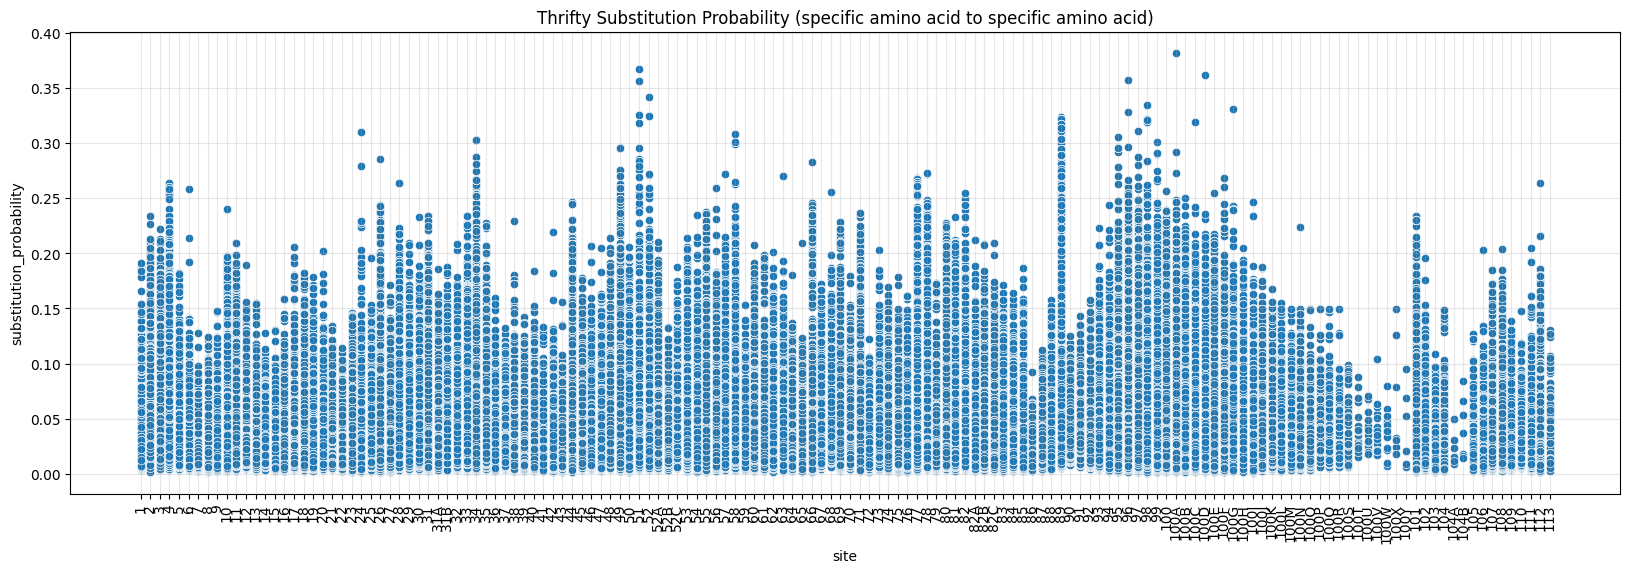

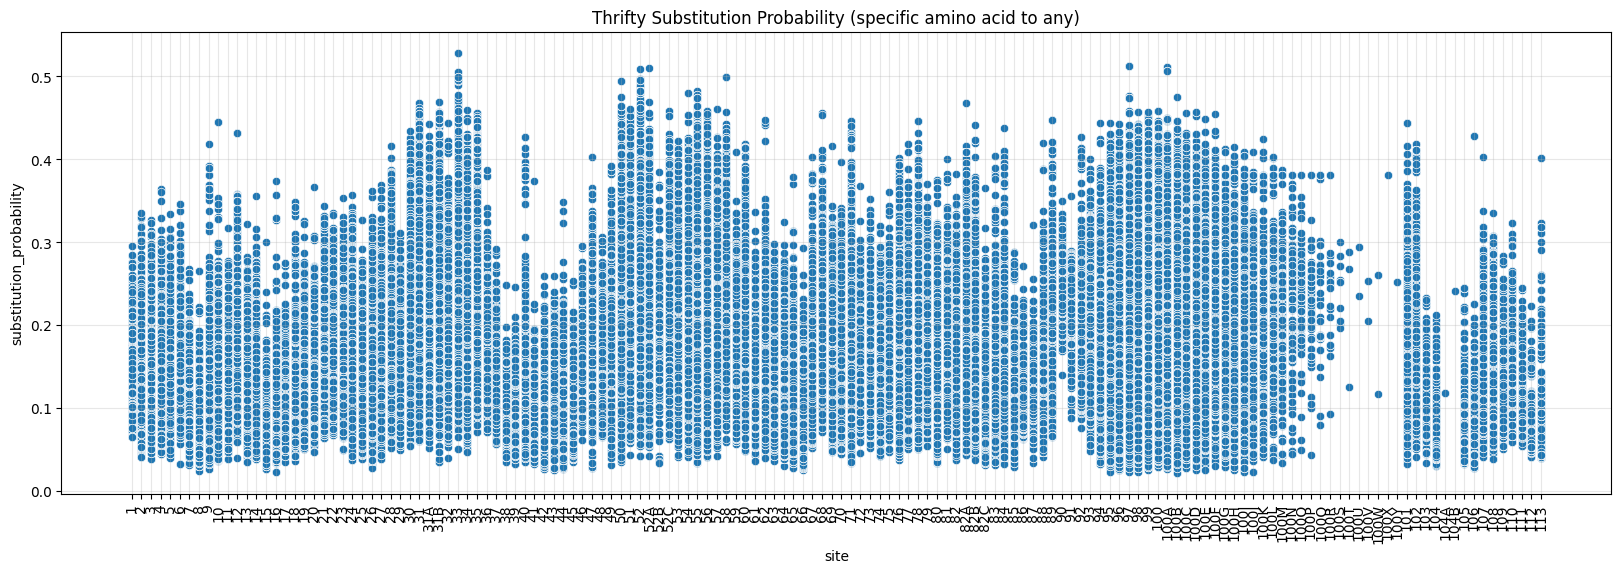

In [7]:
## View subsitution probabilites for specific amino acid to specific amino acid and from specific amino acid to any

# Sort sites properly for both dataframes
sorted_sites_aa = sort_antibody_sites(MutabilityContainer.aa_neutral_df['site'].unique())
sorted_sites_aa_to_any = sort_antibody_sites(MutabilityContainer.aa_to_any_neutral_df['site'].unique())

# Convert to categorical with proper ordering
MutabilityContainer.aa_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.aa_neutral_df['site'],
    categories=sorted_sites_aa,
    ordered=True
)

MutabilityContainer.aa_to_any_neutral_df['site'] = pd.Categorical(
    MutabilityContainer.aa_to_any_neutral_df['site'],
    categories=sorted_sites_aa_to_any,
    ordered=True
)

# Plot 1: specific amino acid to specific amino acid
fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(len(sorted_sites_aa)), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to specific amino acid)')



# Plot 2: specific amino acid to any
fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_to_any_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(len(sorted_sites_aa_to_any)), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to any)')

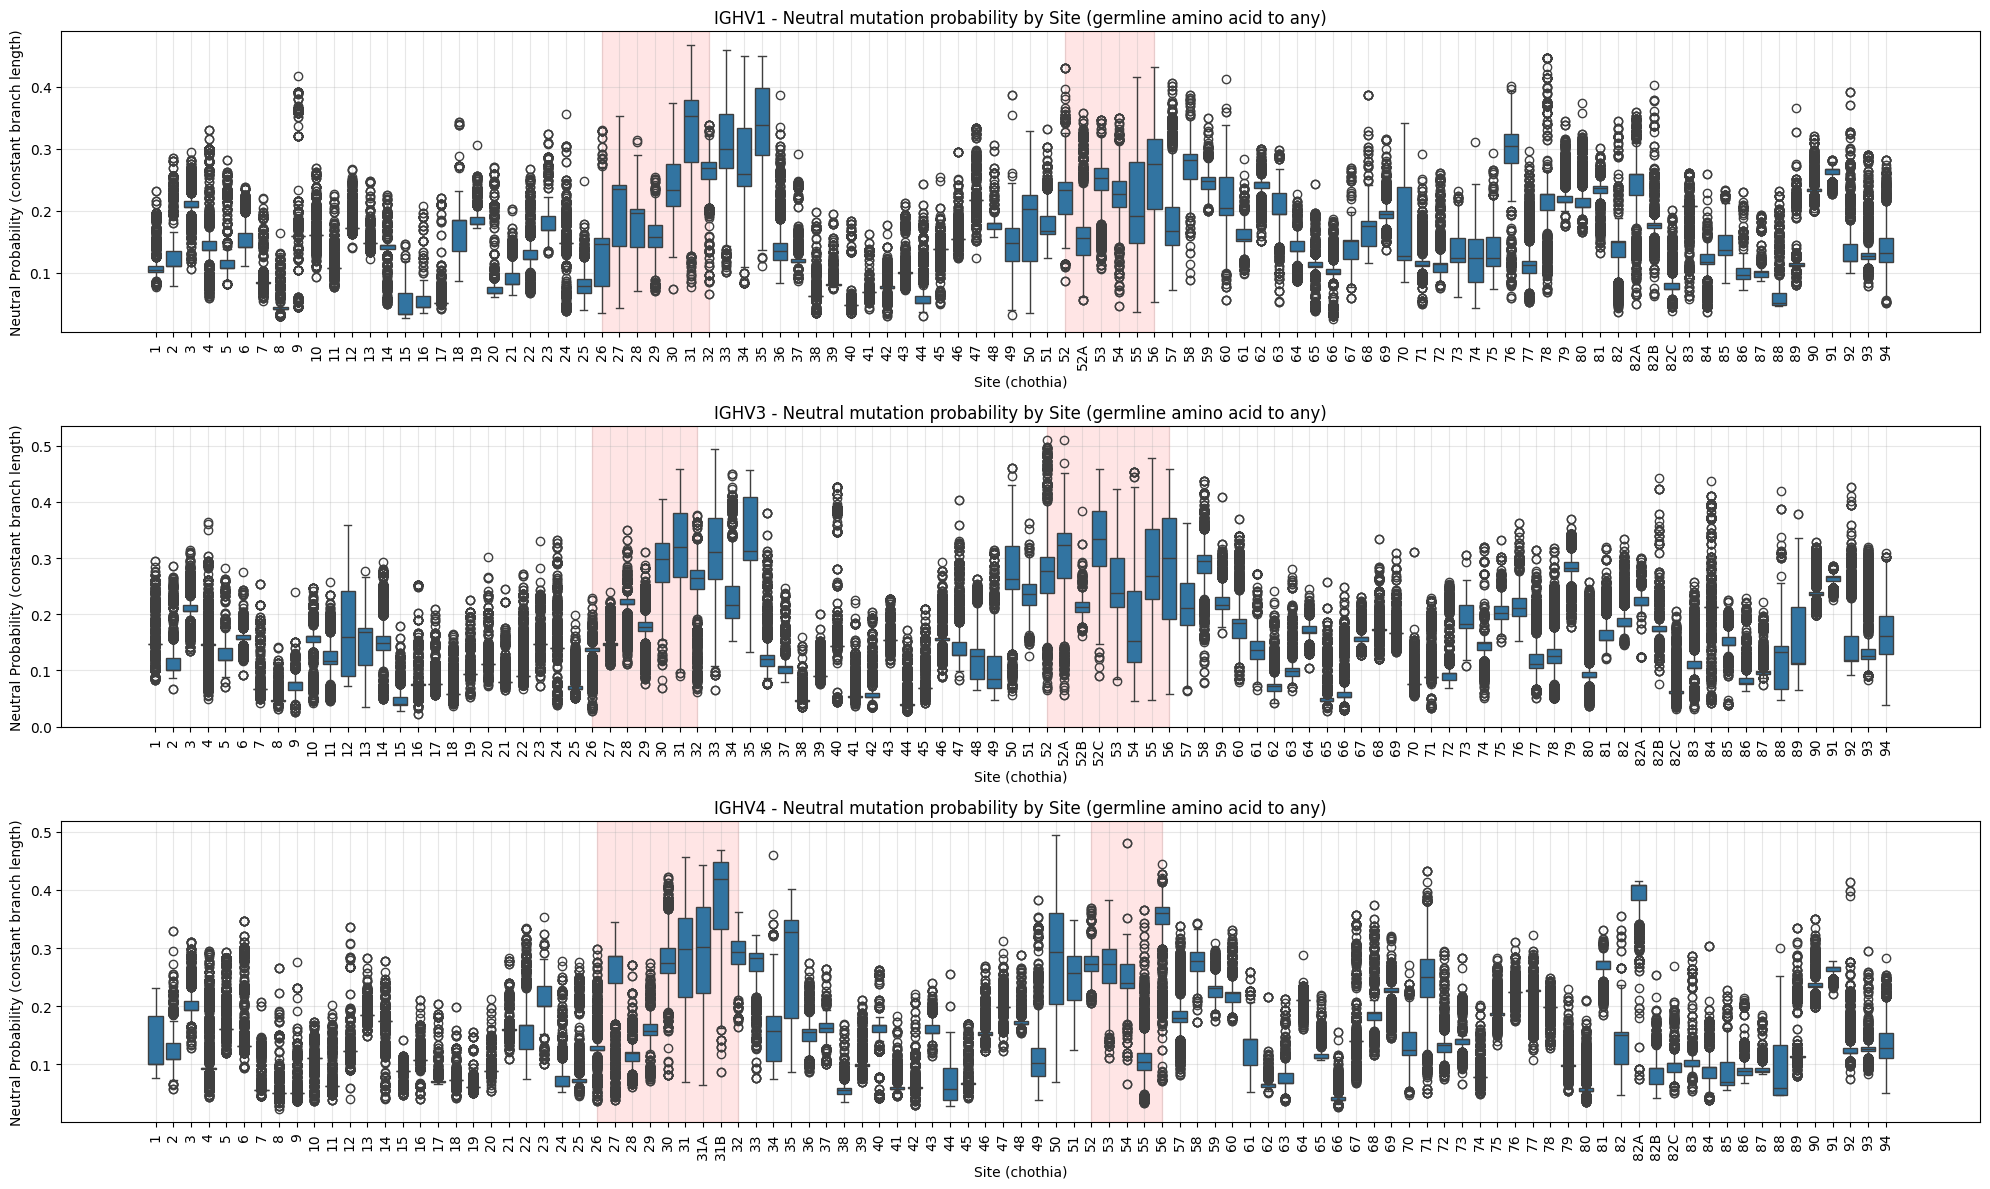

In [8]:
# View distributions of substitution probabilities for specific amino acid to any amino acid by site, per V family

fig, axes = plt.subplots(3, 1, figsize=(20, 12))

v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, v_family in enumerate(v_families):
    # Filter data for current V family
    plot_data = MutabilityContainer.aa_to_any_neutral_df[
        (MutabilityContainer.aa_to_any_neutral_df.v_family == v_family) & 
        (MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True)
    ].copy()
    
    # Get all unique sites and sort them properly (handles both IMGT and Chothia)
    all_sites = sort_antibody_sites(plot_data['site'].unique())
    site_to_pos = {str(site): pos for pos, site in enumerate(all_sites)}
    
    # Map sites to positions for plotting
    plot_data['site_pos'] = plot_data['site'].astype(str).map(site_to_pos)
    
    # Get all unique pcp_index values to create dummy rows for missing sites
    unique_pcps = plot_data['pcp_index'].unique()
    
    # Create a complete grid of all pcp_index x site_pos combinations
    complete_grid = []
    for pcp in unique_pcps:
        for pos in range(len(all_sites)):
            complete_grid.append({'pcp_index': pcp, 'site_pos': pos})
    
    complete_df = pd.DataFrame(complete_grid)
    
    # Merge with actual data, filling missing values with NaN
    plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site_pos'], how='left')
    
    # Create the boxplot with complete data (NaN values will be ignored automatically)
    sns.boxplot(data=plot_data_complete, x='site_pos', y='substitution_probability', ax=axes[i])
    
    # Set x-axis ticks to show every 2nd or 3rd site to avoid crowding
    step = max(1, len(all_sites) // 60)
    tick_positions = range(0, len(all_sites), step)
    axes[i].set_xticks(tick_positions)
    axes[i].set_xticklabels([all_sites[j] for j in tick_positions], rotation=90)
    
    # Add minor grid lines
    axes[i].set_xticks(range(len(all_sites)), minor=True)
    axes[i].grid(True, alpha=0.3)
    axes[i].grid(True, which='minor', alpha=0.1)
    
    # Add labels
    axes[i].set_xlabel(f'Site ({numbering_scheme})')
    axes[i].set_ylabel('Neutral Probability (constant branch length)')
    axes[i].set_title(f'{v_family} - Neutral mutation probability by Site (germline amino acid to any)')
    
    # Add CDR shading using the utility function (handles both IMGT and Chothia)
    add_cdr_shading(axes[i], all_sites, numbering_scheme=numbering_scheme, chain='heavy')

plt.tight_layout()
plt.show()


### Entrenchment Site Classification - within v family and between



In [9]:
# Load entrenchment data using utility function
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, SITE_COLOR_MAP, within_dfs, vs_dfs = load_entrenched_sites(numbering_scheme)

print(f"Total entrenched sites: {len(entrenched_sites)}")
print(f"Total entrenched site-AA pairs: {len(entrenched_sites_aas)}")

# Get sorted list of all entrenched sites for consistent ordering
all_entrenched_sites = sort_antibody_sites(entrenched_sites_aas['site'].unique()) if not entrenched_sites_aas.empty else []

# Get within-only sites for categorization
entrenched_within_sites = sorted(within_dfs['site'].unique()) if not within_dfs.empty and 'site' in within_dfs.columns else []
vs_only_sites_set = set(vs_dfs['site'].unique()) if not vs_dfs.empty and 'site' in vs_dfs.columns else set()


Total entrenched sites: 44
Total entrenched site-AA pairs: 113


## compare thrifty rates (from specific aa to any) to DNSM

In [10]:
site_sub_probs_df, total_pcp_df = load_and_process_dnsm_data(model_name = "dnsm_1m-v1jaffe+v1tang-joint", dataset_name='v1rodriguez', numbering_scheme=numbering_scheme)

site_sub_probs_df['is_cdr'] = site_sub_probs_df['site'].apply(lambda x: is_in_cdr(x, numbering_scheme=numbering_scheme, chain='heavy'))



In [11]:
neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'v_family'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'v_family'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dnsm = pd.merge(neutral_grouped_data, dnsm_grouped_data.rename(columns={'parent_aa':'current_aa'}), on=['site', 'current_aa', 'v_family'], how='inner')
compare_neutral_dnsm['log_selection_factor'] = compare_neutral_dnsm['log_selection_factor'].clip(lower=-4)


/loc/scratch/45928928/ipykernel_6219/3359011417.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(


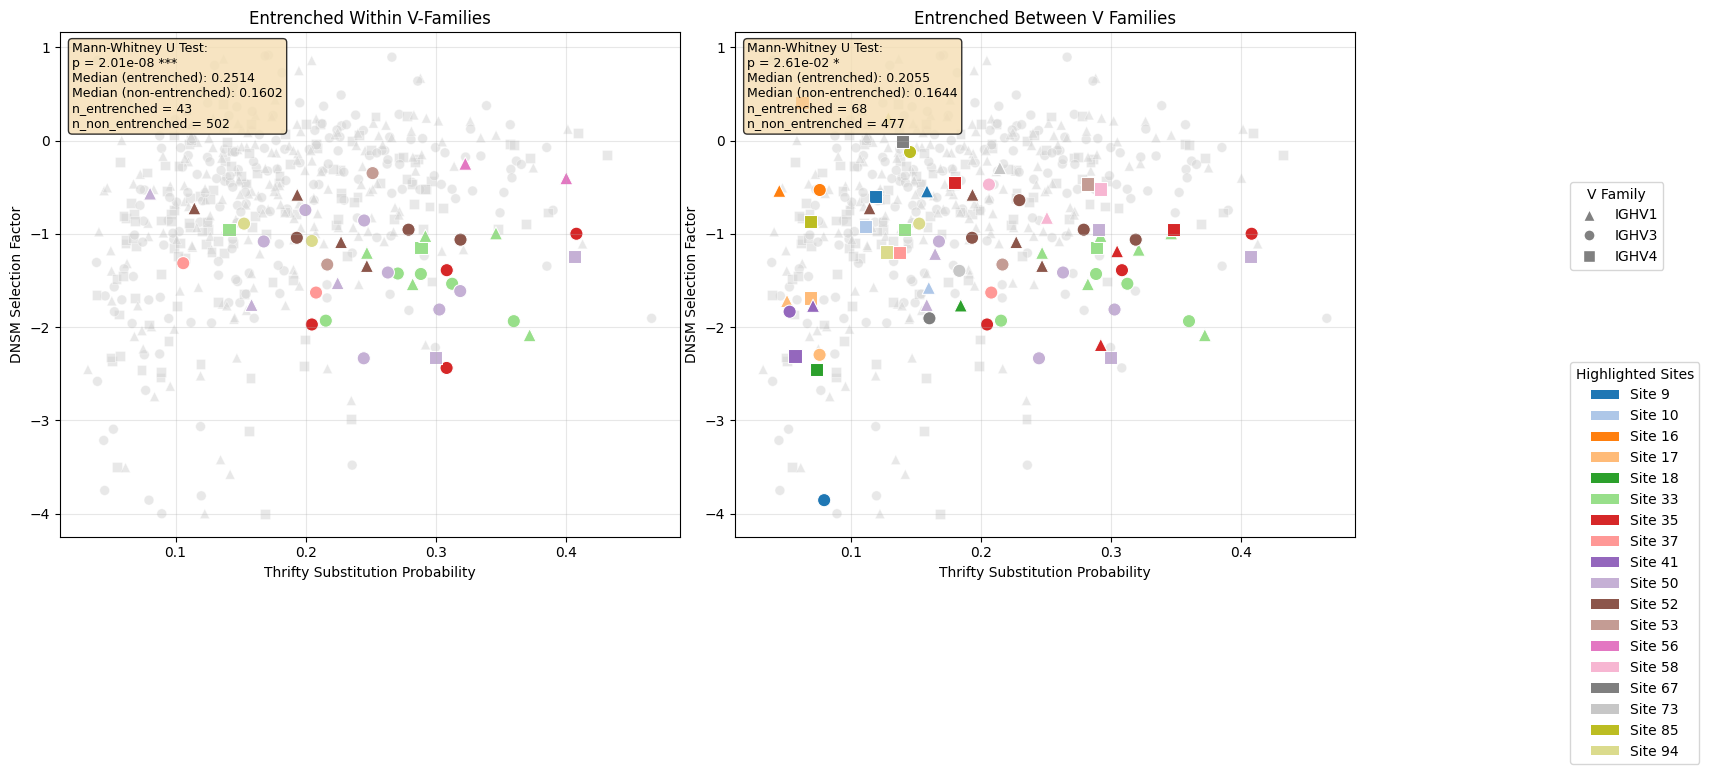

Within families plot: 43 data points
Between families plot: 68 data points
Total unique sites in plots: 18


In [12]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Import statistical test
from scipy.stats import mannwhitneyu

# Custom marker mapping
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}

def plot_entrenchment_category(ax, entrenchment_df, title):
    # Base scatter plot for all data
    sns.scatterplot(data=compare_neutral_dnsm,
                    x='substitution_probability',
                    y='log_selection_factor',
                    style='v_family',
                    markers=marker_map,
                    color='lightgray',
                    s=50,
                    alpha=0.5,
                    ax=ax,
                    legend=False)

    # Overlay entrenched sites with colors
    highlighted_data = pd.merge(compare_neutral_dnsm,
                               entrenchment_df[['v_family', 'site', 'amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa'}),
                               on=['v_family', 'site', 'current_aa'],
                               how='inner')

    if not highlighted_data.empty:
        # Convert site to string for color mapping
        highlighted_data['site'] = highlighted_data['site'].astype(str)

        # Plot with hue='site' and palette=SITE_COLOR_MAP
        sns.scatterplot(data=highlighted_data,
                       x='substitution_probability',
                       y='log_selection_factor',
                       hue='site',
                       style='v_family',
                       markers=marker_map,
                       palette=SITE_COLOR_MAP,
                       s=90,
                       ax=ax,
                       legend=False)
    
    # Perform statistical test
    if not highlighted_data.empty:
        # Get neutral probabilities for entrenched sites
        entrenched_probs = highlighted_data['substitution_probability'].values
        
        # Get neutral probabilities for NON-entrenched sites
        # Create a key to identify entrenched rows
        highlighted_data_copy = highlighted_data.copy()
        highlighted_data_copy['entrenched_key'] = (highlighted_data_copy['v_family'].astype(str) + '_' + 
                                                    highlighted_data_copy['site'].astype(str) + '_' + 
                                                    highlighted_data_copy['current_aa'].astype(str))
        entrenched_keys = set(highlighted_data_copy['entrenched_key'])
        
        # Mark non-entrenched in the full dataset
        compare_neutral_dnsm_copy = compare_neutral_dnsm.copy()
        compare_neutral_dnsm_copy['key'] = (compare_neutral_dnsm_copy['v_family'].astype(str) + '_' + 
                                            compare_neutral_dnsm_copy['site'].astype(str) + '_' + 
                                            compare_neutral_dnsm_copy['current_aa'].astype(str))
        non_entrenched_data = compare_neutral_dnsm_copy[~compare_neutral_dnsm_copy['key'].isin(entrenched_keys)]
        non_entrenched_probs = non_entrenched_data['substitution_probability'].values
        
        # Mann-Whitney U test
        statistic, p_value = mannwhitneyu(entrenched_probs, non_entrenched_probs, alternative='two-sided')
        
        # Add test results to plot
        median_entrenched = np.median(entrenched_probs)
        median_non_entrenched = np.median(non_entrenched_probs)
        
        # Determine significance stars
        if p_value < 0.001:
            sig_str = '***'
        elif p_value < 0.01:
            sig_str = '**'
        elif p_value < 0.05:
            sig_str = '*'
        else:
            sig_str = 'ns'
        
        # Add text box with statistics
        textstr = f'Mann-Whitney U Test:\np = {p_value:.2e} {sig_str}\n'
        textstr += f'Median (entrenched): {median_entrenched:.4f}\n'
        textstr += f'Median (non-entrenched): {median_non_entrenched:.4f}\n'
        textstr += f'n_entrenched = {len(entrenched_probs)}\n'
        textstr += f'n_non_entrenched = {len(non_entrenched_probs)}'
        
        # Add text box to plot
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Thrifty Substitution Probability')
    ax.set_ylabel('DNSM Selection Factor')

    return highlighted_data

# Plot 1: Entrenched within families
within_data = plot_entrenchment_category(ax1, within_dfs,
                                         'Entrenched Within V-Families')

# Plot 2: Variable between but not within families (vs only)
vs_data = plot_entrenchment_category(ax2, vs_dfs,
                                     'Entrenched Between V Families')

# Create legends
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# V-family legend (symbols)
v_family_elements = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray',
                           markersize=8, label=family, linestyle='None')
                    for family, marker in marker_map.items()]

# Site color legend - only for sites that actually appear in the plots
sites_in_plots = set()
if not within_data.empty:
    sites_in_plots.update(within_data['site'].unique())
if not vs_data.empty:
    sites_in_plots.update(vs_data['site'].unique())

# Sort sites properly for legend
sorted_legend_sites = sort_antibody_sites(list(sites_in_plots))

site_elements = [Patch(facecolor=SITE_COLOR_MAP.get(str(site), 'black'),
                      label=f'Site {site}')
                for site in sorted_legend_sites[:20]]  # Limit to first 20 sites for readability

# Add legends to the right of the plots
fig.legend(handles=v_family_elements, title='V Family',
          bbox_to_anchor=(0.98, 0.7), loc='upper left')
fig.legend(handles=site_elements, title='Highlighted Sites',
          bbox_to_anchor=(0.98, 0.4), loc='upper left', ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legends
plt.show()

print(f"Within families plot: {len(within_data) if not within_data.empty else 0} data points")
print(f"Between families plot: {len(vs_data) if not vs_data.empty else 0} data points")
print(f"Total unique sites in plots: {len(sites_in_plots)}")

## compare thrifty rates (from specific aa to specific aa) to DASM


In [13]:
## compare to DASM

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"

_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=model_name, dataset_name=dataset_name, numbering_scheme=numbering_scheme)


Adding one_mutation_away column (vectorized)...


In [14]:
neutral_grouped_data = MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'transition_aa', 'v_family'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dasm_grouped_data = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'selection_factor_target_aa', 'v_family', 'one_mutation_away'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dasm = pd.merge(neutral_grouped_data, dasm_grouped_data.rename(columns={'parent_aa':'current_aa', 'selection_factor_target_aa':'transition_aa'}), on=['site', 'current_aa', 'transition_aa', 'v_family'], how='inner')
compare_neutral_dasm['log_selection_factor'] = compare_neutral_dasm['log_selection_factor'].clip(lower=-4)
compare_neutral_dasm = compare_neutral_dasm[compare_neutral_dasm.one_mutation_away == True]
compare_neutral_dasm['is_cdr'] = compare_neutral_dasm['site'].apply(lambda x: is_in_cdr(x, numbering_scheme=numbering_scheme, chain='heavy'))



/loc/scratch/45928928/ipykernel_6219/1847154311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neutral_grouped_data = MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(


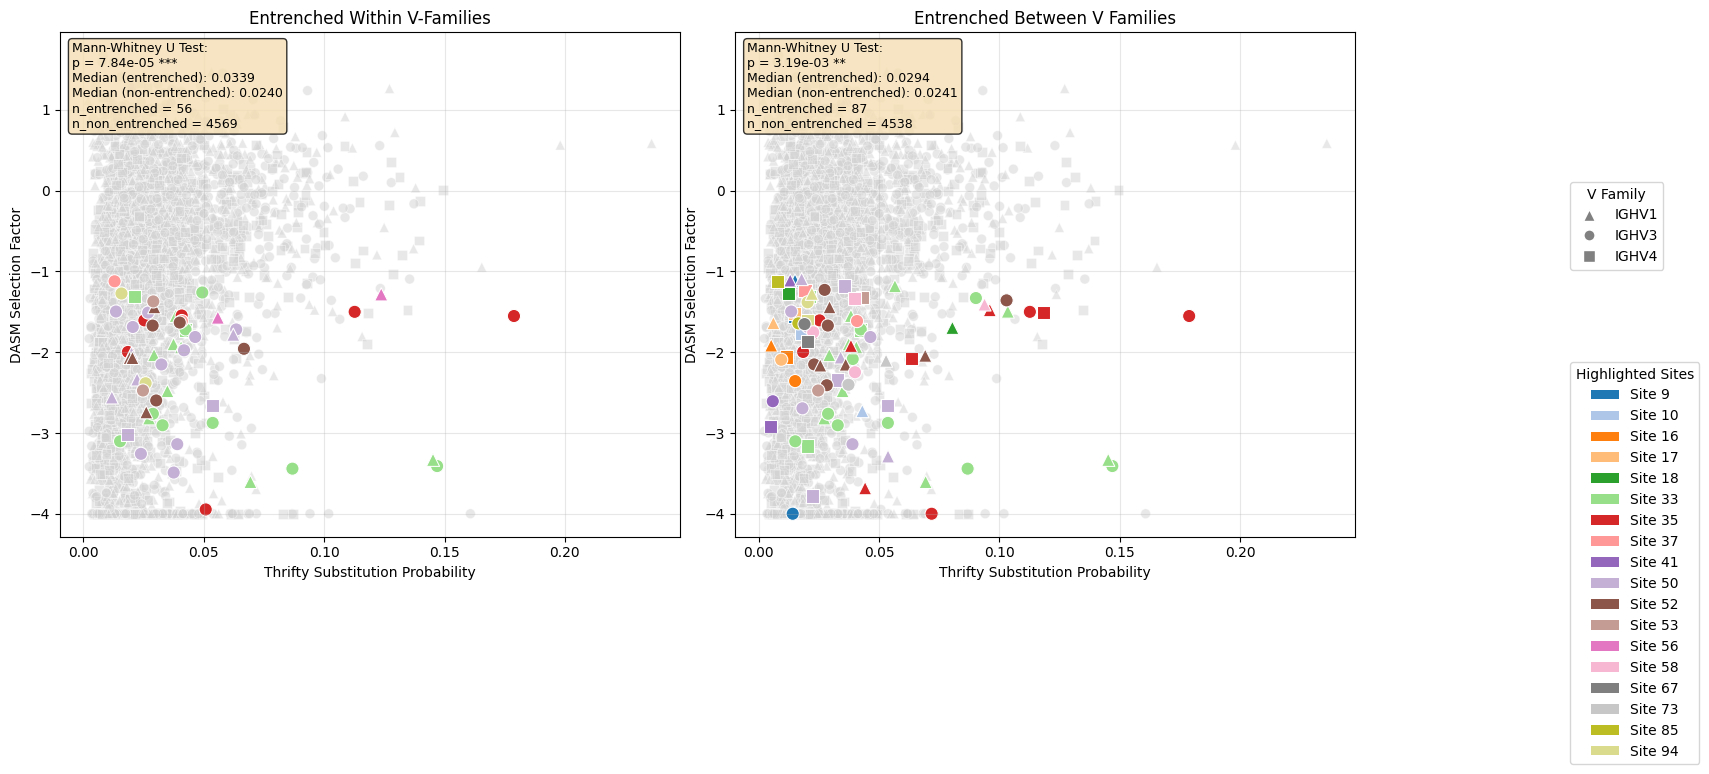

Within families plot: 56 data points
Between families plot: 87 data points
Total unique sites in plots: 18


In [15]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Import statistical test
from scipy.stats import mannwhitneyu

# Custom marker mapping
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}

def plot_entrenchment_category(ax, entrenchment_df, title):
    # Base scatter plot for all data
    sns.scatterplot(data=compare_neutral_dasm,
                    x='substitution_probability',
                    y='log_selection_factor',
                    style='v_family',
                    markers=marker_map,
                    color='lightgray',
                    s=50,
                    alpha=0.5,
                    ax=ax,
                    legend=False)

    # Overlay entrenched sites with colors
    highlighted_data = pd.merge(compare_neutral_dasm,
                               entrenchment_df[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'}),
                               on=['v_family', 'site', 'current_aa', 'transition_aa'],
                               how='inner')

    if not highlighted_data.empty:
        # Convert site to string for color mapping
        highlighted_data['site'] = highlighted_data['site'].astype(str)

        # Plot with hue='site' and palette=SITE_COLOR_MAP
        sns.scatterplot(data=highlighted_data,
                       x='substitution_probability',
                       y='log_selection_factor',
                       hue='site',
                       style='v_family',
                       markers=marker_map,
                       palette=SITE_COLOR_MAP,
                       s=90,
                       ax=ax,
                       legend=False)
    
    # Perform statistical test
    if not highlighted_data.empty:
        # Get neutral probabilities for entrenched sites
        entrenched_probs = highlighted_data['substitution_probability'].values
        
        # Get neutral probabilities for NON-entrenched sites
        # Create a key to identify entrenched rows
        highlighted_data_copy = highlighted_data.copy()
        highlighted_data_copy['entrenched_key'] = (highlighted_data_copy['v_family'].astype(str) + '_' + 
                                                    highlighted_data_copy['site'].astype(str) + '_' + 
                                                    highlighted_data_copy['current_aa'].astype(str)) + '_' + \
                                                    highlighted_data_copy['transition_aa'].astype(str)
        entrenched_keys = set(highlighted_data_copy['entrenched_key'])
        
        # Mark non-entrenched in the full dataset
        compare_neutral_dasm_copy = compare_neutral_dasm.copy()
        compare_neutral_dasm_copy['key'] = (compare_neutral_dasm_copy['v_family'].astype(str) + '_' + 
                                            compare_neutral_dasm_copy['site'].astype(str) + '_' + 
                                            compare_neutral_dasm_copy['current_aa'].astype(str)) + '_' + \
                                            compare_neutral_dasm_copy['transition_aa'].astype(str)
        non_entrenched_data = compare_neutral_dasm_copy[~compare_neutral_dasm_copy['key'].isin(entrenched_keys)]
        non_entrenched_probs = non_entrenched_data['substitution_probability'].values
        # Mann-Whitney U test
        statistic, p_value = mannwhitneyu(entrenched_probs, non_entrenched_probs, alternative='two-sided')
        
        # Add test results to plot
        median_entrenched = np.median(entrenched_probs)
        median_non_entrenched = np.median(non_entrenched_probs)
        
        # Determine significance stars
        if p_value < 0.001:
            sig_str = '***'
        elif p_value < 0.01:
            sig_str = '**'
        elif p_value < 0.05:
            sig_str = '*'
        else:
            sig_str = 'ns'
        
        # Add text box with statistics
        textstr = f'Mann-Whitney U Test:\np = {p_value:.2e} {sig_str}\n'
        textstr += f'Median (entrenched): {median_entrenched:.4f}\n'
        textstr += f'Median (non-entrenched): {median_non_entrenched:.4f}\n'
        textstr += f'n_entrenched = {len(entrenched_probs)}\n'
        textstr += f'n_non_entrenched = {len(non_entrenched_probs)}'
        
        # Add text box to plot
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Thrifty Substitution Probability')
    ax.set_ylabel('DASM Selection Factor')

    return highlighted_data

# Plot 1: Entrenched within families
within_data = plot_entrenchment_category(ax1, within_dfs,
                                         'Entrenched Within V-Families')

# Plot 2: Variable between but not within families (vs only)
vs_data = plot_entrenchment_category(ax2, vs_dfs,
                                     'Entrenched Between V Families')

# Create legends
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# V-family legend (symbols)
v_family_elements = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray',
                           markersize=8, label=family, linestyle='None')
                    for family, marker in marker_map.items()]

# Site color legend - only for sites that actually appear in the plots
sites_in_plots = set()
if not within_data.empty:
    sites_in_plots.update(within_data['site'].unique())
if not vs_data.empty:
    sites_in_plots.update(vs_data['site'].unique())

# Sort sites properly for legend
sorted_legend_sites = sort_antibody_sites(list(sites_in_plots))

site_elements = [Patch(facecolor=SITE_COLOR_MAP.get(str(site), 'black'),
                      label=f'Site {site}')
                for site in sorted_legend_sites[:20]]  # Limit to first 20 sites for readability

# Add legends to the right of the plots
fig.legend(handles=v_family_elements, title='V Family',
          bbox_to_anchor=(0.98, 0.7), loc='upper left')
fig.legend(handles=site_elements, title='Highlighted Sites',
          bbox_to_anchor=(0.98, 0.4), loc='upper left', ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legends
plt.show()

print(f"Within families plot: {len(within_data) if not within_data.empty else 0} data points")
print(f"Between families plot: {len(vs_data) if not vs_data.empty else 0} data points")
print(f"Total unique sites in plots: {len(sites_in_plots)}")

## Neutral rates correlate with germline diversity?
Weak but significant correlation. Higher than selection factor correlation.

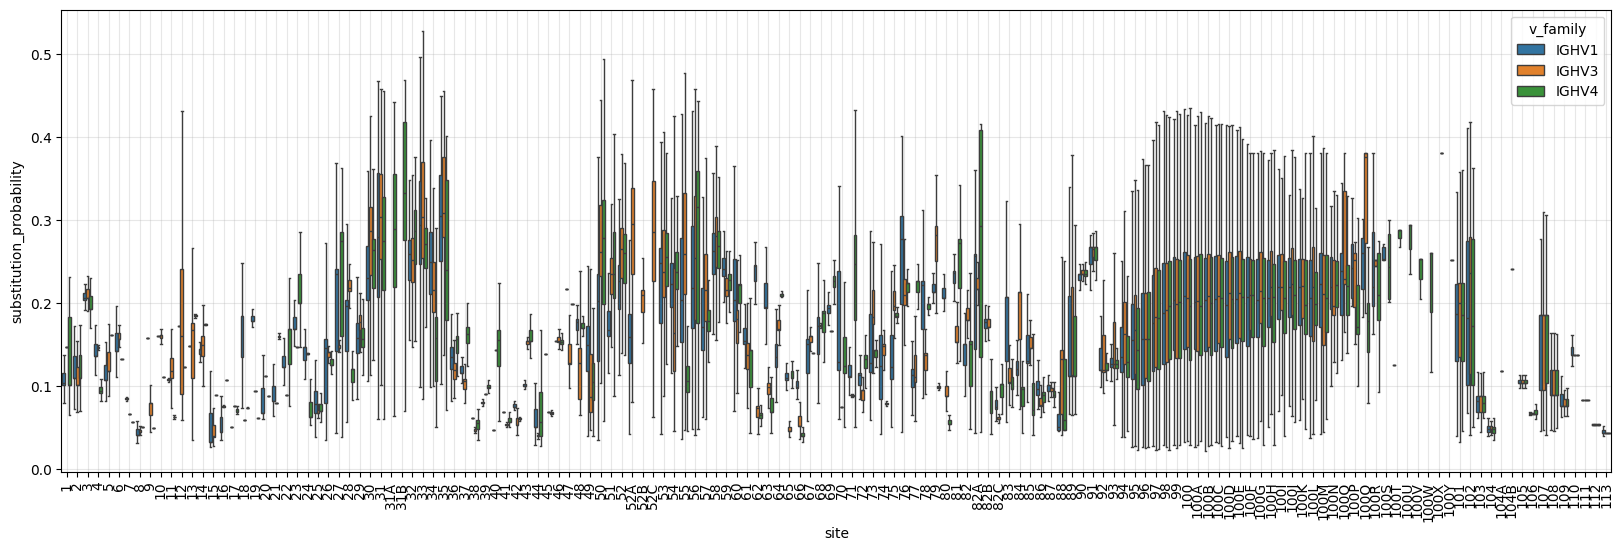

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(MutabilityContainer.aa_to_any_neutral_df, x='site', y='substitution_probability', hue='v_family', hue_order=['IGHV1', 'IGHV3', 'IGHV4'], ax=ax, showfliers=False)
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

In [17]:
germline_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})
germline_df = germline_df[germline_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])]

# Sort sites properly
sorted_sites = sort_antibody_sites(germline_df['site'].unique())

# Convert to categorical with proper ordering
germline_df['site'] = pd.Categorical(germline_df['site'], categories=sorted_sites, ordered=True)


/loc/scratch/45928928/ipykernel_6219/202199536.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shannon_per_site = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()


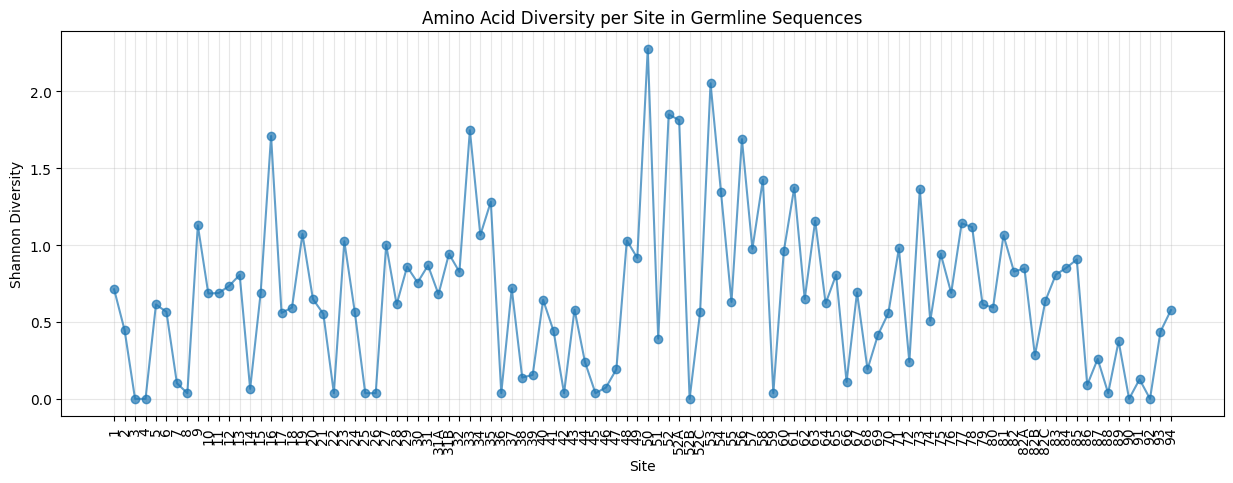

In [18]:
# calculate shannon diversity per site for V1, V3, V4 germline sequences toget


def shannon_diversity(series):
    """
    Calculate Shannon diversity index for amino acid variability.
    
    Shannon diversity measures how evenly distributed different amino acids are at a position.
    It ranges from 0 (completely conserved) to ~3.0 (maximum diversity).
    
    Formula: H = -Σ(p_i * ln(p_i)) where p_i is the proportion of amino acid i
    
    Interpretation:
    - H = 0: Completely conserved (one amino acid only)
    - H ≈ 0.7: Low diversity (2-3 amino acids with uneven distribution)
    - H ≈ 1.4-2.0: Moderate diversity (several amino acids)
    - H > 2.5: High diversity (many amino acids with relatively even distribution)
    - H_max ≈ 3.0 (ln(20)): Maximum possible for 20 amino acids equally distributed
    
    Parameters
    ----------
    series : pd.Series
        Series of amino acid characters
    
    Returns
    -------
    float
        Shannon diversity index (using natural logarithm)
    """
    counts = series.value_counts()
    proportions = counts / counts.sum()
    return -np.sum(proportions * np.log(proportions))

# Calculate Shannon diversity per site
shannon_per_site = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
shannon_per_site.columns = ['site', 'shannon_diversity']

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(shannon_per_site['site'], shannon_per_site['shannon_diversity'], 'o-', alpha=0.7)
plt.xlabel('Site')
plt.ylabel('Shannon Diversity')
plt.title('Amino Acid Diversity per Site in Germline Sequences')
# rotate x labels
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.show()


/loc/scratch/45928928/ipykernel_6219/1136889841.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diversity_by_family = germline_df.groupby(['v_family', 'site'])['amino_acid'].agg([



IGHV1 - Sites with highest diversity:
   site  shannon_diversity  num_unique_aa
57   53           1.665216              7
58   54           1.611180              6
60   56           1.588536              6
53   52           1.412440              6
77   73           1.323495              5

IGHV3 - Sites with highest diversity:
    site  shannon_diversity  num_unique_aa
153   50           2.102364             10
136   33           1.886003              9
162   56           1.729499              8
159   53           1.466567              6
155   52           1.461852              7

IGHV4 - Sites with highest diversity:
    site  shannon_diversity  num_unique_aa
219   16           1.179404              4
255   50           1.052972              4
236  31B           0.943348              3
261   53           0.900256              3
238   33           0.831185              3

Shannon diversity comparison across families (first 20 sites):
v_family     IGHV1     IGHV3     IGHV4
site        

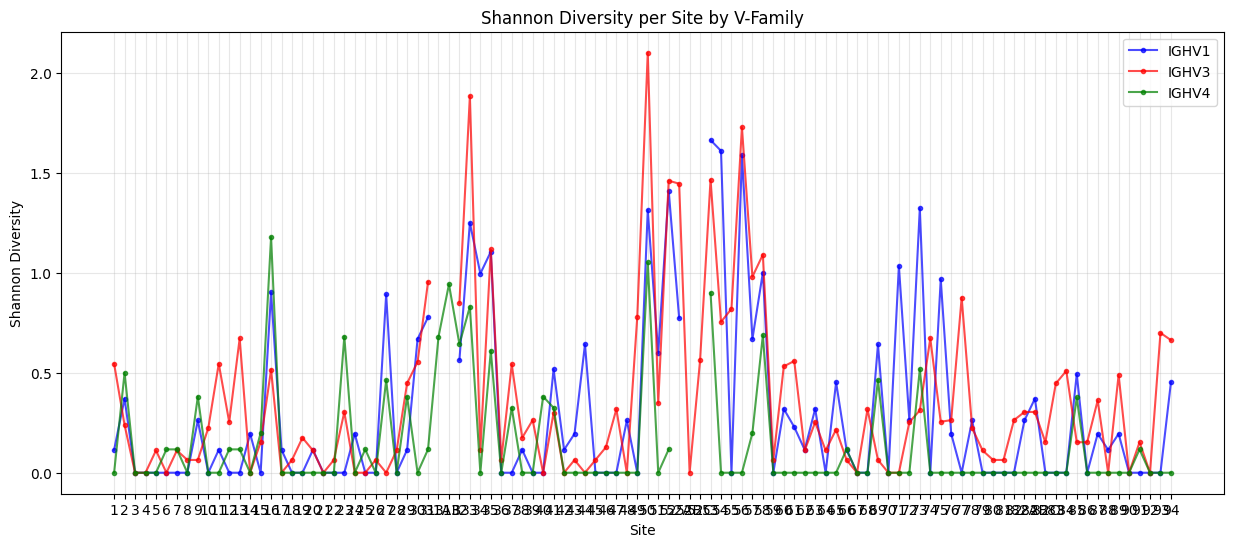

In [19]:
# calculate shannon diversity per site for each v famile V1, V3, V4 


# Calculate Shannon diversity per site within each v_family
diversity_by_family = germline_df.groupby(['v_family', 'site'])['amino_acid'].agg([
    ('num_unique_aa', 'nunique'),
    ('total_v_genes', 'count'),
    ('shannon_diversity', shannon_diversity)
]).reset_index()

# View results for each family
for family in ['IGHV1', 'IGHV3', 'IGHV4']:
    family_data = diversity_by_family[diversity_by_family['v_family'] == family]
    print(f"\n{family} - Sites with highest diversity:")
    print(family_data.nlargest(5, 'shannon_diversity')[['site', 'shannon_diversity', 'num_unique_aa']])

# Compare diversity across families for the same sites
pivot_diversity = diversity_by_family.pivot(index='site', columns='v_family', values='shannon_diversity').fillna(0)
print("\nShannon diversity comparison across families (first 20 sites):")
print(pivot_diversity.head(20))

# Calculate average diversity per family
avg_diversity = diversity_by_family.groupby('v_family')['shannon_diversity'].agg(['mean', 'std', 'count'])
print("\nAverage Shannon diversity per v_family:")
print(avg_diversity)

plt.figure(figsize=(15, 6))

for family, color in zip(['IGHV1', 'IGHV3', 'IGHV4'], ['blue', 'red', 'green']):
    family_data = diversity_by_family[diversity_by_family['v_family'] == family]
    plt.plot(family_data['site'], family_data['shannon_diversity'], 
             'o-', color=color, alpha=0.7, label=family, markersize=3)

plt.xlabel('Site')
plt.ylabel('Shannon Diversity')
plt.title('Shannon Diversity per Site by V-Family')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/loc/scratch/45928928/ipykernel_6219/3505669113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(


/loc/scratch/45928928/ipykernel_6219/3505669113.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()


Correlations for All Data (Pooled across V-families):
Shannon Diversity vs Substitution Probability:
  r = 0.409, r² = 0.167, p = 0.000
Shannon Diversity vs Log Selection Factor:
  r = 0.390, r² = 0.152, p = 0.000
Shannon Diversity vs Selection Factor:
  r = 0.320, r² = 0.102, p = 0.001
Sample size: 102 sites


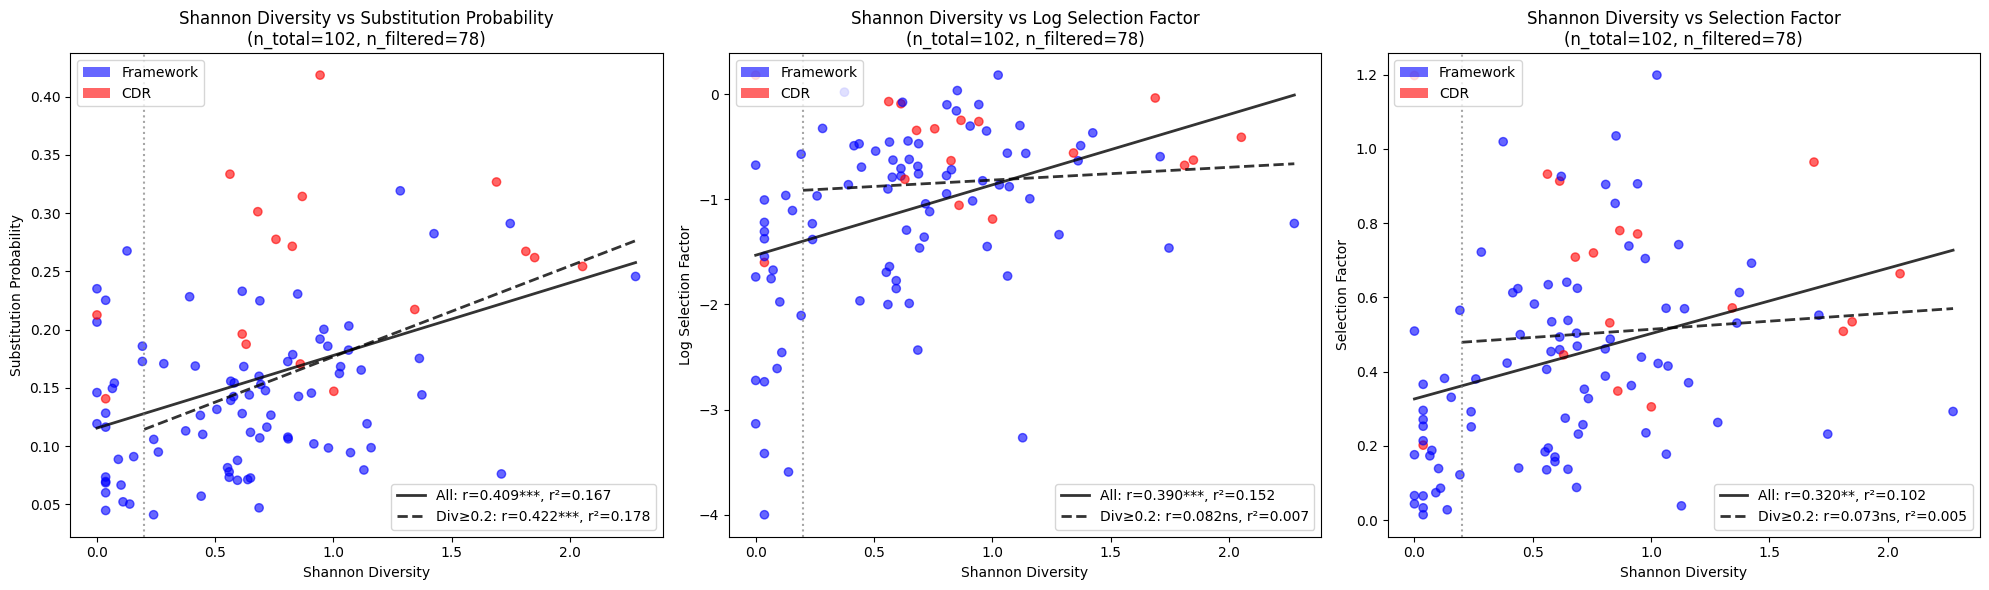

Solid line = regression using all data
Dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [20]:
# compare neutral substitution probabilities and DNSM selection factors with shannon diversity
# group per site (all v families together). 
# Only use amino acids at their germline state to calculate median substitution probabilities.

neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'is_cdr'], sort=False).agg({'log_selection_factor':'median', 'selection_factor':'median'}).reset_index()

compare_neutral_dnsm3 = pd.merge(neutral_grouped_data, dnsm_grouped_data, on=['site', ], how='inner')
compare_neutral_dnsm3['log_selection_factor'] = compare_neutral_dnsm3['log_selection_factor'].clip(lower=-4)


# Calculate diversity across all families (pooled)
diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
diversity_all_families.columns = ['site', 'shannon_diversity']

# Merge with your grouped data
merged_all_data = pd.merge(compare_neutral_dnsm3, diversity_all_families, on='site', how='inner')

# Add selection factor (non-log) if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])

# Calculate correlations for all data pooled together
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

# Calculate r-squared
r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Display results
print("Correlations for All Data (Pooled across V-families):")
print(f"Shannon Diversity vs Substitution Probability:")
print(f"  r = {corr_subst_all:.3f}, r² = {r2_subst_all:.3f}, p = {p_subst_all:.3f}")
print(f"Shannon Diversity vs Log Selection Factor:")
print(f"  r = {corr_log_sel_all:.3f}, r² = {r2_log_sel_all:.3f}, p = {p_log_sel_all:.3f}")
print(f"Shannon Diversity vs Selection Factor:")
print(f"  r = {corr_sel_all:.3f}, r² = {r2_sel_all:.3f}, p = {p_sel_all:.3f}")
print(f"Sample size: {len(merged_all_data)} sites")


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))  # Added third subplot

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Filter data for second regression (diversity >= 0.2)
filtered_data = merged_all_data[merged_all_data['shannon_diversity'] >= 0.2]

# Add selection factor if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])
    filtered_data['selection_factor'] = np.exp(filtered_data['log_selection_factor'])

# Calculate correlations for both datasets
# All data
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Filtered data (diversity >= 0.2)
corr_subst_filt, p_subst_filt = pearsonr(filtered_data['shannon_diversity'], 
                                        filtered_data['substitution_probability'])
corr_log_sel_filt, p_log_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                            filtered_data['log_selection_factor'])
corr_sel_filt, p_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                    filtered_data['selection_factor'])

r2_subst_filt = corr_subst_filt ** 2
r2_log_sel_filt = corr_log_sel_filt ** 2
r2_sel_filt = corr_sel_filt ** 2

# Plot 1: Shannon vs Substitution Probability
ax1.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['substitution_probability'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z1_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['substitution_probability'], 1)
p1_all = np.poly1d(z1_all)
x_range_all = np.linspace(merged_all_data['shannon_diversity'].min(), 
                         merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_all, p1_all(x_range_all), "k-", alpha=0.8, linewidth=2, 
         label=f'All: r={corr_subst_all:.3f}{get_significance_stars(p_subst_all)}, r²={r2_subst_all:.3f}')

z1_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['substitution_probability'], 1)
p1_filt = np.poly1d(z1_filt)
x_range_filt = np.linspace(0.2, merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_filt, p1_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_subst_filt:.3f}{get_significance_stars(p_subst_filt)}, r²={r2_subst_filt:.3f}')

ax1.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax1.set_title(f'Shannon Diversity vs Substitution Probability\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax1.set_xlabel('Shannon Diversity')
ax1.set_ylabel('Substitution Probability')

# Plot 2: Shannon vs Log Selection Factor
ax2.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['log_selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z2_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['log_selection_factor'], 1)
p2_all = np.poly1d(z2_all)
ax2.plot(x_range_all, p2_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_log_sel_all:.3f}{get_significance_stars(p_log_sel_all)}, r²={r2_log_sel_all:.3f}')

z2_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['log_selection_factor'], 1)
p2_filt = np.poly1d(z2_filt)
ax2.plot(x_range_filt, p2_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_log_sel_filt:.3f}{get_significance_stars(p_log_sel_filt)}, r²={r2_log_sel_filt:.3f}')

ax2.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax2.set_title(f'Shannon Diversity vs Log Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax2.set_xlabel('Shannon Diversity')
ax2.set_ylabel('Log Selection Factor')

# Plot 3: Shannon vs Selection Factor (NEW)
ax3.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z3_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['selection_factor'], 1)
p3_all = np.poly1d(z3_all)
ax3.plot(x_range_all, p3_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_sel_all:.3f}{get_significance_stars(p_sel_all)}, r²={r2_sel_all:.3f}')

z3_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['selection_factor'], 1)
p3_filt = np.poly1d(z3_filt)
ax3.plot(x_range_filt, p3_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_sel_filt:.3f}{get_significance_stars(p_sel_filt)}, r²={r2_sel_filt:.3f}')

ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax3.set_title(f'Shannon Diversity vs Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax3.set_xlabel('Shannon Diversity')
ax3.set_ylabel('Selection Factor')

# Add legends to all plots
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR')]

for ax in [ax1, ax2, ax3]:
    ax_legend = ax.legend(handles=legend_elements, loc='upper left')
    ax.add_artist(ax_legend)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Solid line = regression using all data")
print("Dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

/loc/scratch/45928928/ipykernel_6219/4152852843.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(


Correlation Results by V-Family:
  v_family  n_sites  pearson_subst_prob  p_value_subst_prob  pearson_log_sel  \
0    IGHV1       98              0.3961              0.0001           0.2796   
1    IGHV3      100              0.5841              0.0000           0.3192   
2    IGHV4       99              0.3908              0.0001           0.1717   

   p_value_log_sel  spearman_subst_prob  spearman_p_subst_prob  \
0           0.0053               0.2566                 0.0108   
1           0.0012               0.4387                 0.0000   
2           0.0892               0.2798                 0.0050   

   spearman_log_sel  spearman_p_log_sel  
0            0.2962              0.0031  
1            0.4445              0.0000  
2            0.1603              0.1130  


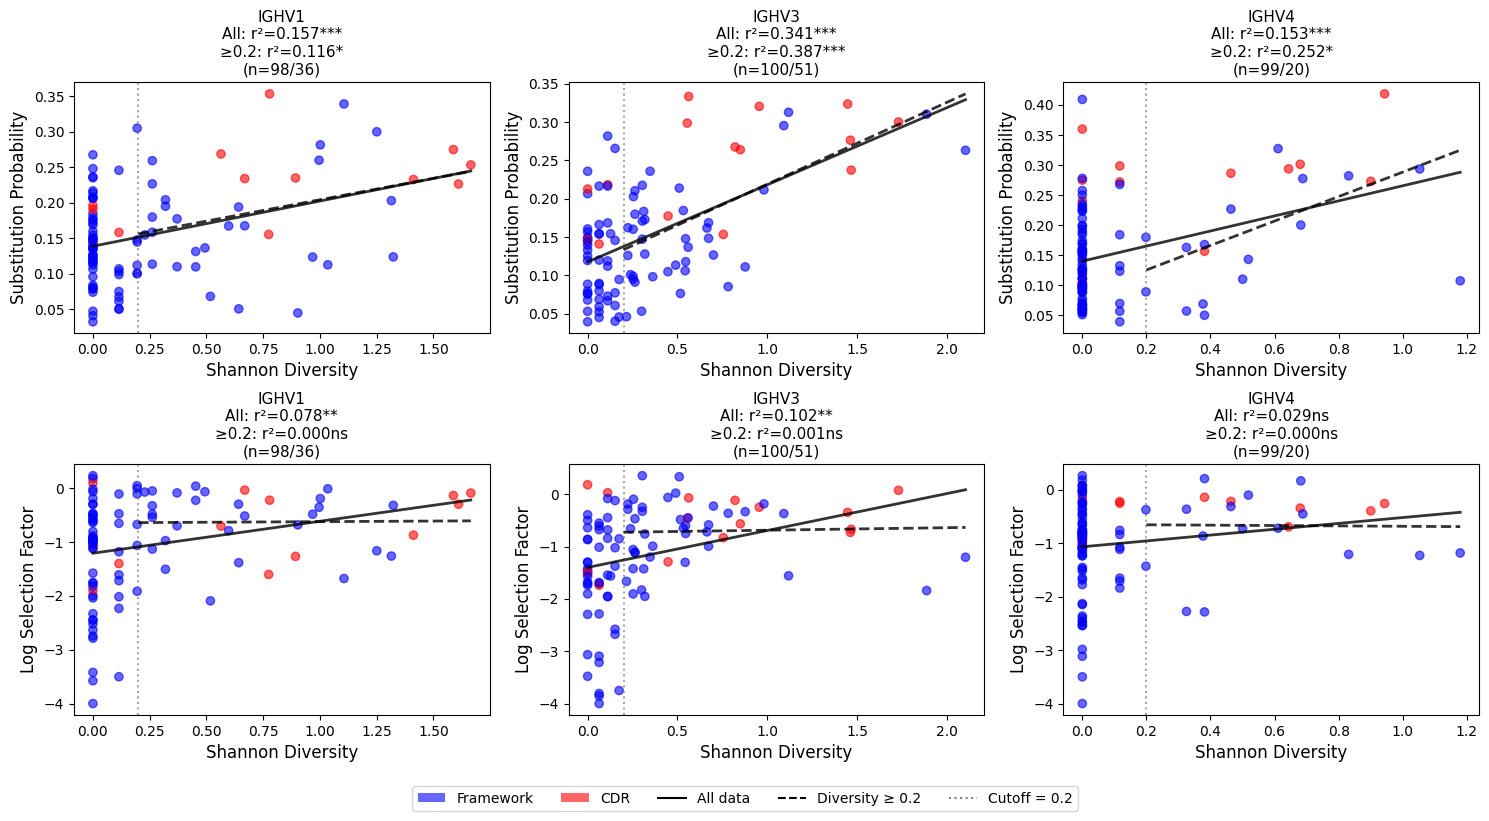

Blue = Framework regions, Red = CDR regions
Black solid line = regression using all data
Black dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant
n = total sites / filtered sites


In [21]:
# compare neutral substitution probabilities and DNSM selection factors with shannon diversity
# group per site and v family. 
# Only use amino acids at their germline state to calculate median substitution probabilities.

neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'v_family'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'v_family', 'is_cdr'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dnsm2 = pd.merge(neutral_grouped_data, dnsm_grouped_data, on=['site', 'v_family'], how='inner')
compare_neutral_dnsm2['log_selection_factor'] = compare_neutral_dnsm2['log_selection_factor'].clip(lower=-4)



# Merge the datasets
merged_data = pd.merge(diversity_by_family, 
                       compare_neutral_dnsm2.groupby(['site', 'v_family', 'is_cdr']).agg({'substitution_probability':'mean', 'log_selection_factor':'mean'}).reset_index(), 
                      left_on=['site', 'v_family'], 
                      right_on=['site', 'v_family'], 
                      how='inner')

# Calculate correlations for each v_family
correlation_results = []

for family in ['IGHV1', 'IGHV3', 'IGHV4']:
    family_data = merged_data[merged_data['v_family'] == family]
    
    if len(family_data) > 2:  # Need at least 3 points for correlation
        # Pearson correlations
        corr_subst_prob, p_subst_prob = pearsonr(family_data['shannon_diversity'], 
                                                family_data['substitution_probability'])
        corr_log_sel, p_log_sel = pearsonr(family_data['shannon_diversity'], 
                                          family_data['log_selection_factor'])
        
        # Spearman correlations (rank-based, more robust)
        spear_subst_prob, sp_subst_prob = spearmanr(family_data['shannon_diversity'], 
                                                   family_data['substitution_probability'])
        spear_log_sel, sp_log_sel = spearmanr(family_data['shannon_diversity'], 
                                             family_data['log_selection_factor'])
        
        correlation_results.append({
            'v_family': family,
            'n_sites': len(family_data),
            'pearson_subst_prob': corr_subst_prob,
            'p_value_subst_prob': p_subst_prob,
            'pearson_log_sel': corr_log_sel,
            'p_value_log_sel': p_log_sel,
            'spearman_subst_prob': spear_subst_prob,
            'spearman_p_subst_prob': sp_subst_prob,
            'spearman_log_sel': spear_log_sel,
            'spearman_p_log_sel': sp_log_sel
        })

# Display results
corr_df = pd.DataFrame(correlation_results)
print("Correlation Results by V-Family:")
print(corr_df.round(4))



fig, axes = plt.subplots(2, 3, figsize=(15, 8))

families = ['IGHV1', 'IGHV3', 'IGHV4']

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

for i, family in enumerate(families):
    family_data = merged_data[merged_data['v_family'] == family]
    family_filtered = family_data[family_data['shannon_diversity'] >= 0.2]
    
    # Calculate correlations for all data
    corr_subst, p_subst = pearsonr(family_data['shannon_diversity'], 
                                  family_data['substitution_probability'])
    corr_log_sel, p_log_sel = pearsonr(family_data['shannon_diversity'], 
                                      family_data['log_selection_factor'])
    r2_subst = corr_subst ** 2
    r2_log_sel = corr_log_sel ** 2
    
    # Calculate correlations for filtered data (diversity >= 0.2)
    if len(family_filtered) > 2:
        corr_subst_filt, p_subst_filt = pearsonr(family_filtered['shannon_diversity'], 
                                                family_filtered['substitution_probability'])
        corr_log_sel_filt, p_log_sel_filt = pearsonr(family_filtered['shannon_diversity'], 
                                                    family_filtered['log_selection_factor'])
        r2_subst_filt = corr_subst_filt ** 2
        r2_log_sel_filt = corr_log_sel_filt ** 2
    
    # Top row: Shannon vs Substitution Probability
    # Color by CDR/Framework
    axes[0, i].scatter(family_data['shannon_diversity'], 
                      family_data['substitution_probability'], 
                      alpha=0.6, 
                      c=family_data['is_cdr'].map({True: 'red', False: 'blue'}))
    axes[0, i].set_xlabel('Shannon Diversity', fontsize=12)
    axes[0, i].set_ylabel('Substitution Probability', fontsize=12)
    axes[0, i].tick_params(axis='both', which='major', labelsize=10)
    
    # Add vertical line at diversity = 0.2
    axes[0, i].axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
    
    # Regression line for all data
    z = np.polyfit(family_data['shannon_diversity'], 
                   family_data['substitution_probability'], 1)
    p = np.poly1d(z)
    x_range_all = np.linspace(family_data['shannon_diversity'].min(),
                             family_data['shannon_diversity'].max(), 100)
    axes[0, i].plot(x_range_all, p(x_range_all), "-", color='black', alpha=0.8, linewidth=2)
    
    # Regression line for filtered data (diversity >= 0.2) if enough points
    if len(family_filtered) > 2:
        z_filt = np.polyfit(family_filtered['shannon_diversity'], 
                           family_filtered['substitution_probability'], 1)
        p_filt = np.poly1d(z_filt)
        x_range_filt = np.linspace(max(0.2, family_data['shannon_diversity'].min()),
                                  family_data['shannon_diversity'].max(), 100)
        axes[0, i].plot(x_range_filt, p_filt(x_range_filt), "--", color='black', alpha=0.8, linewidth=2)
    
    # Title with correlation info (only r²)
    sig_stars = get_significance_stars(p_subst)
    title_text = f'{family}\nAll: r²={r2_subst:.3f}{sig_stars}'
    if len(family_filtered) > 2:
        sig_stars_filt = get_significance_stars(p_subst_filt)
        title_text += f'\n≥0.2: r²={r2_subst_filt:.3f}{sig_stars_filt}'
        title_text += f'\n(n={len(family_data)}/{len(family_filtered)})'
    else:
        title_text += f'\n(n={len(family_data)}, insufficient filtered data)'
    axes[0, i].set_title(title_text, fontsize=11)
    
    # Bottom row: Shannon vs Log Selection Factor
    axes[1, i].scatter(family_data['shannon_diversity'], 
                      family_data['log_selection_factor'], 
                      alpha=0.6,
                      c=family_data['is_cdr'].map({True: 'red', False: 'blue'}))
    axes[1, i].set_xlabel('Shannon Diversity', fontsize=12)
    axes[1, i].set_ylabel('Log Selection Factor', fontsize=12)
    axes[1, i].tick_params(axis='both', which='major', labelsize=10)
    
    # Add vertical line at diversity = 0.2
    axes[1, i].axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
    
    # Regression line for all data
    z2 = np.polyfit(family_data['shannon_diversity'], 
                    family_data['log_selection_factor'], 1)
    p2 = np.poly1d(z2)
    axes[1, i].plot(x_range_all, p2(x_range_all), "-", color='black', alpha=0.8, linewidth=2)
    
    # Regression line for filtered data (diversity >= 0.2) if enough points
    if len(family_filtered) > 2:
        z2_filt = np.polyfit(family_filtered['shannon_diversity'], 
                            family_filtered['log_selection_factor'], 1)
        p2_filt = np.poly1d(z2_filt)
        axes[1, i].plot(x_range_filt, p2_filt(x_range_filt), "--", color='black', alpha=0.8, linewidth=2)
    
    # Title with correlation info (only r²)
    sig_stars2 = get_significance_stars(p_log_sel)
    title_text2 = f'{family}\nAll: r²={r2_log_sel:.3f}{sig_stars2}'
    if len(family_filtered) > 2:
        sig_stars2_filt = get_significance_stars(p_log_sel_filt)
        title_text2 += f'\n≥0.2: r²={r2_log_sel_filt:.3f}{sig_stars2_filt}'
        title_text2 += f'\n(n={len(family_data)}/{len(family_filtered)})'
    else:
        title_text2 += f'\n(n={len(family_data)}, insufficient filtered data)'
    axes[1, i].set_title(title_text2, fontsize=11)

# Add a single legend for the entire figure
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR'),
                  plt.Line2D([0], [0], color='black', linestyle='-', label='All data'),
                  plt.Line2D([0], [0], color='black', linestyle='--', label='Diversity ≥ 0.2'),
                  plt.Line2D([0], [0], color='gray', linestyle=':', label='Cutoff = 0.2')]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=5, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Make room for legend
plt.show()

print("Blue = Framework regions, Red = CDR regions")
print("Black solid line = regression using all data")
print("Black dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("n = total sites / filtered sites")

Correlations for All Data (Pooled across V-families):
Shannon Diversity vs Substitution Probability:
  r = 0.411, r² = 0.169, p = 0.000
Shannon Diversity vs Log Selection Factor:
  r = 0.382, r² = 0.146, p = 0.000
Shannon Diversity vs Selection Factor:
  r = 0.328, r² = 0.108, p = 0.000
Sample size: 297 sites


/loc/scratch/45928928/ipykernel_6219/1003810972.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()


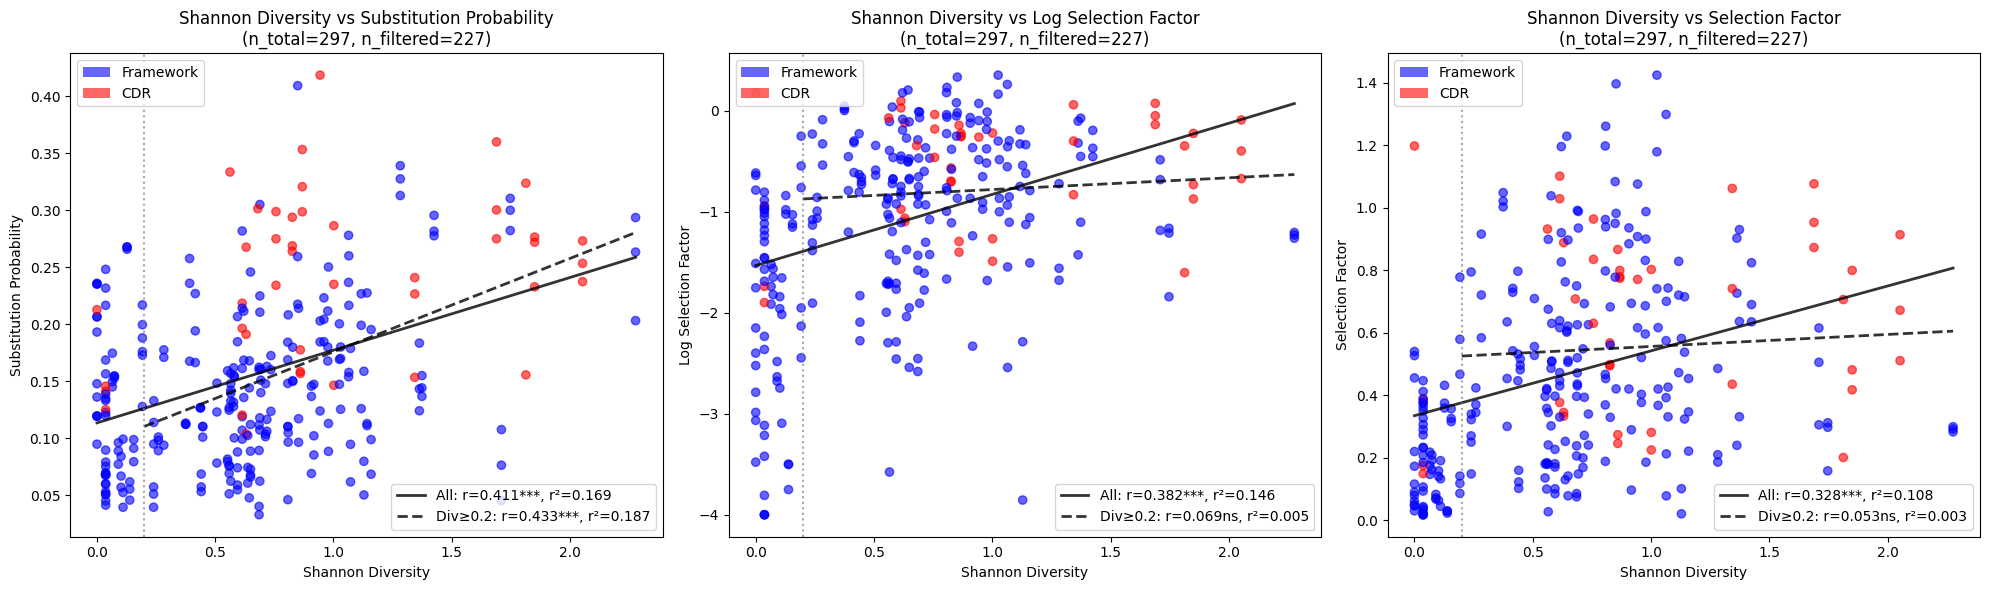

Solid line = regression using all data
Dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [22]:
# same as previous cell, but pooling all families together in the same plot and correlation


# Calculate diversity across all families (pooled)
diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
diversity_all_families.columns = ['site', 'shannon_diversity']

# Merge with your grouped data
merged_all_data = pd.merge(compare_neutral_dnsm2, diversity_all_families, on='site', how='inner')

# Add selection factor (non-log) if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])

# Calculate correlations for all data pooled together
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

# Calculate r-squared
r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Display results
print("Correlations for All Data (Pooled across V-families):")
print(f"Shannon Diversity vs Substitution Probability:")
print(f"  r = {corr_subst_all:.3f}, r² = {r2_subst_all:.3f}, p = {p_subst_all:.3f}")
print(f"Shannon Diversity vs Log Selection Factor:")
print(f"  r = {corr_log_sel_all:.3f}, r² = {r2_log_sel_all:.3f}, p = {p_log_sel_all:.3f}")
print(f"Shannon Diversity vs Selection Factor:")
print(f"  r = {corr_sel_all:.3f}, r² = {r2_sel_all:.3f}, p = {p_sel_all:.3f}")
print(f"Sample size: {len(merged_all_data)} sites")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))  # Added third subplot

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Filter data for second regression (diversity >= 0.2)
filtered_data = merged_all_data[merged_all_data['shannon_diversity'] >= 0.2]

# Add selection factor if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])
    filtered_data['selection_factor'] = np.exp(filtered_data['log_selection_factor'])

# Calculate correlations for both datasets
# All data
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Filtered data (diversity >= 0.2)
corr_subst_filt, p_subst_filt = pearsonr(filtered_data['shannon_diversity'], 
                                        filtered_data['substitution_probability'])
corr_log_sel_filt, p_log_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                            filtered_data['log_selection_factor'])
corr_sel_filt, p_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                    filtered_data['selection_factor'])

r2_subst_filt = corr_subst_filt ** 2
r2_log_sel_filt = corr_log_sel_filt ** 2
r2_sel_filt = corr_sel_filt ** 2

# Plot 1: Shannon vs Substitution Probability
ax1.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['substitution_probability'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z1_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['substitution_probability'], 1)
p1_all = np.poly1d(z1_all)
x_range_all = np.linspace(merged_all_data['shannon_diversity'].min(), 
                         merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_all, p1_all(x_range_all), "k-", alpha=0.8, linewidth=2, 
         label=f'All: r={corr_subst_all:.3f}{get_significance_stars(p_subst_all)}, r²={r2_subst_all:.3f}')

z1_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['substitution_probability'], 1)
p1_filt = np.poly1d(z1_filt)
x_range_filt = np.linspace(0.2, merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_filt, p1_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_subst_filt:.3f}{get_significance_stars(p_subst_filt)}, r²={r2_subst_filt:.3f}')

ax1.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax1.set_title(f'Shannon Diversity vs Substitution Probability\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax1.set_xlabel('Shannon Diversity')
ax1.set_ylabel('Substitution Probability')

# Plot 2: Shannon vs Log Selection Factor
ax2.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['log_selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z2_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['log_selection_factor'], 1)
p2_all = np.poly1d(z2_all)
ax2.plot(x_range_all, p2_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_log_sel_all:.3f}{get_significance_stars(p_log_sel_all)}, r²={r2_log_sel_all:.3f}')

z2_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['log_selection_factor'], 1)
p2_filt = np.poly1d(z2_filt)
ax2.plot(x_range_filt, p2_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_log_sel_filt:.3f}{get_significance_stars(p_log_sel_filt)}, r²={r2_log_sel_filt:.3f}')

ax2.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax2.set_title(f'Shannon Diversity vs Log Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax2.set_xlabel('Shannon Diversity')
ax2.set_ylabel('Log Selection Factor')

# Plot 3: Shannon vs Selection Factor (NEW)
ax3.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z3_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['selection_factor'], 1)
p3_all = np.poly1d(z3_all)
ax3.plot(x_range_all, p3_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_sel_all:.3f}{get_significance_stars(p_sel_all)}, r²={r2_sel_all:.3f}')

z3_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['selection_factor'], 1)
p3_filt = np.poly1d(z3_filt)
ax3.plot(x_range_filt, p3_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_sel_filt:.3f}{get_significance_stars(p_sel_filt)}, r²={r2_sel_filt:.3f}')

ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax3.set_title(f'Shannon Diversity vs Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax3.set_xlabel('Shannon Diversity')
ax3.set_ylabel('Selection Factor')

# Add legends to all plots
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR')]

for ax in [ax1, ax2, ax3]:
    ax_legend = ax.legend(handles=legend_elements, loc='upper left')
    ax.add_artist(ax_legend)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Solid line = regression using all data")
print("Dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")